Model training completed.


d:\Cache\Conda\envs\EHR\lib\site-packages\xgboost\core.py:729: UserWarning: [21:25:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


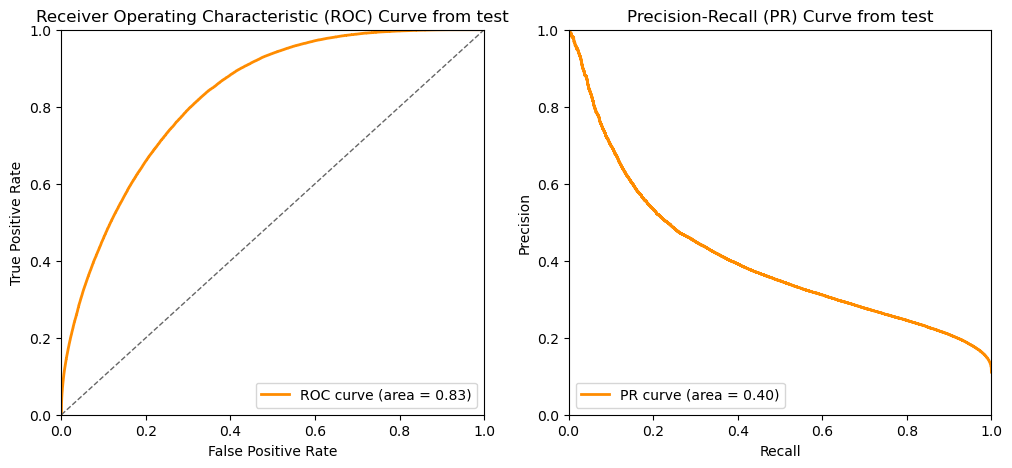

AUROC: 0.8279
AUPRC: 0.4017


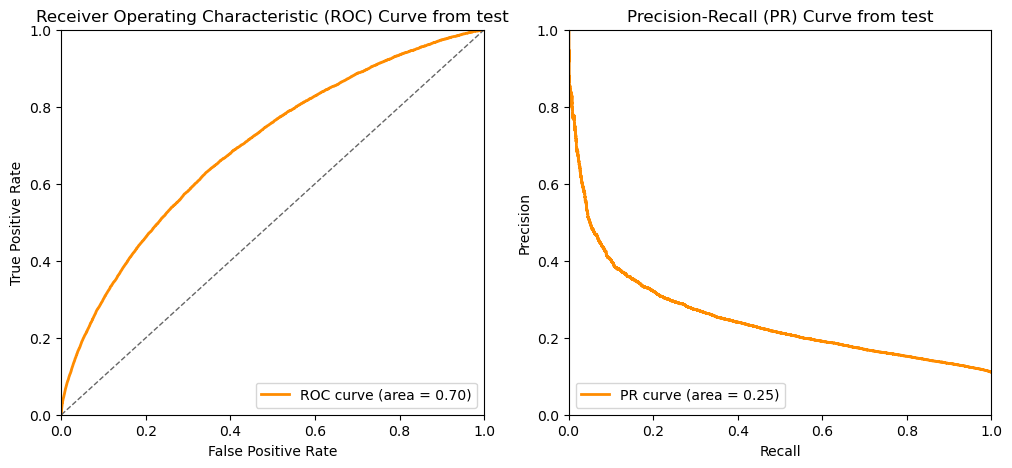

AUROC: 0.6952
AUPRC: 0.2497


[0.6952049757376056,
 0.6884889816212006,
 0.6985190558297363,
 0.8825285150836798,
 0.10736914600550965,
 0.9788809560497885,
 0.38723298559364133,
 0.8981917868476451,
 0.16812250620079802]

In [1]:
from ehr_models import *
import ehr_utils
import pandas as pd
# drop mean bayesian
fill_method='mean'

file_path = f'data_cleaned/ver-noelectrolyte-logtransform_{fill_method}.csv'

X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(file_path, train_size=0.8, random_state=42)

## 需要测试哪个模型就取消注释对应的行,需要默认参数default=True，需要优化后的参数 默认=false
default = False
# model = init_adaBoost(default_parm=default)
# model = init_decisionTree(default_parm=default)
# model = init_gaussianNB(default_parm=default)
# model = init_gradientBoosting(default_parm=default)
# model = init_lightGBM(default_parm=default)
# model = init_linearDiscriminantAnalysis(default_parm=default)
# model = init_logisticRegression(default_parm=default)
# model = init_MLPClassifier(default_parm=default)
# model = init_randomForest(default_parm=default)
model = init_XGBoost(default_parm=default)

model.fit(X_train, Y_train)
print("Model training completed.")
Y_prob, Y_pred = ehr_utils.get_prediction_results(model, X_test)
Ytrain_prob, Ytrain_pred = ehr_utils.get_prediction_results(model, X_train)
ehr_utils.plot_roc_pr_curves(Y_train, Ytrain_prob, 'dt')
ehr_utils.plot_roc_pr_curves(Y_test, Y_prob, 'xgb')
ehr_utils.eval_model(Y_test, Y_prob, Y_pred)

In [6]:
import pickle
with open(f'trained_models_default/{fill_method}/DecisionTree_0.65.pkl', 'wb') as f:
    pickle.dump(model, f)